#**Building RNN for Sentiment Classification**

#Importing dataset direct from kaggle website

In [40]:
import kagglehub
path = kagglehub.dataset_download("vishakhdapat/imdb-movie-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-movie-reviews


In [41]:
import os
import pandas as pd

In [42]:
for file in os.listdir(path):
    print(file)

IMDB Dataset.csv


In [43]:
csv_file = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(csv_file)

In [44]:
df.sample(6)

,review,sentiment
22367,This is a very sad movie. Really. Nothing happ...,negative
8608,There are some wonderful things about this mov...,positive
45309,"Demer Daves,is a wonderful director when it co...",negative
20001,I just watched this movie on Starz. Let me go ...,negative
19761,Saw this at Newport Beach Film Festival the ot...,positive
3582,I rented this movie today thinking it might be...,negative


In [45]:
df.columns.to_list()

['review', 'sentiment']

In [46]:
print("Rows : ",df.shape[0],"\tColumns: ",df.shape[1])

Rows :  50000 	Columns:  2


In [47]:
df.isnull().sum()

,0
review,0
sentiment,0


In [48]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [49]:
df["target"]=df["sentiment"].map({"positive":1,"negative":0})

In [50]:
df.sample(6)

,review,sentiment,target
7410,seriously people need to lighten up and just a...,positive,1
30149,The only good thing about this film is they ma...,negative,0
16897,"""The Notorious Bettie Page"" is about a woman w...",positive,1
37743,"Sweet, rich valley girl develops crush on a pu...",positive,1
8495,Why would Burt Lancaster allow himself to play...,negative,0
47691,"A dozen bored surfers, mostly kids in Venice, ...",positive,1



#Text Cleaning Function

In [51]:
import re

def clean_text(text):

  text=re.sub(r'<.*?>',' ',text)
  text=re.sub(r"[^a-zA-Z\s']",' ',text)
  text=re.sub(r'\s+',' ',text)
  text=re.sub(r'\s+',' ',text).strip()
  text=text.lower() #lower every word

  return text
df['clean_review']=df["review"].apply(clean_text)
print(df['review'].sample(3))
print(df['clean_review'].sample(3))

37907    The crew of an American submarine discover it'...
43709    The first installment of this notorious horror...
21150    This movie starts out brisk, has some slow mom...
Name: review, dtype: object
33146    my first hugely disappointing bbc jane austen ...
28092    a struggling actor finds the best way to break...
24886    this movie was advertised on radio television ...
Name: clean_review, dtype: object


#Train_test Split


In [52]:
x=df['clean_review'].values
y=df['target'].values

In [70]:
from sklearn.model_selection import train_test_split

#Train_Test
x_train_full,x_test,y_train_full,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

#Train_Validation
x_train,x_val,y_train,y_val=train_test_split(x_train_full,y_train_full,test_size=0.10,random_state=42,stratify=y_train_full)

print("Train: ",len(x_train),"\nValidation: ",len(x_val),"\nTest: ",len(x_test))

Train:  36000 
Validation:  4000 
Test:  10000


#Tokenization

In [71]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [72]:
vocab=10000

token=Tokenizer(num_words=vocab,oov_token="<OOV>")
token.fit_on_texts(x_train)

#converting text to integer sequences
x_train_seq=token.texts_to_sequences(x_train)
x_val_seq=token.texts_to_sequences(x_val)
x_test_seq=token.texts_to_sequences(x_test)

print("vocabulary size: ",len(token.word_index))

vocabulary size:  103047


#Sequence Length Distribution


In [73]:
sequence_len=[len(seq) for seq in x_train_seq]

import numpy as np

print("Minimum Length:", np.min(sequence_len))
print("Maximum Length:", np.max(sequence_len))
print("Average Length:", np.mean(sequence_len))
print("Median Length :", np.median(sequence_len))

Minimum Length: 6
Maximum Length: 2462
Average Length: 230.08241666666666
Median Length : 172.0


In [74]:
import matplotlib.pyplot as plt

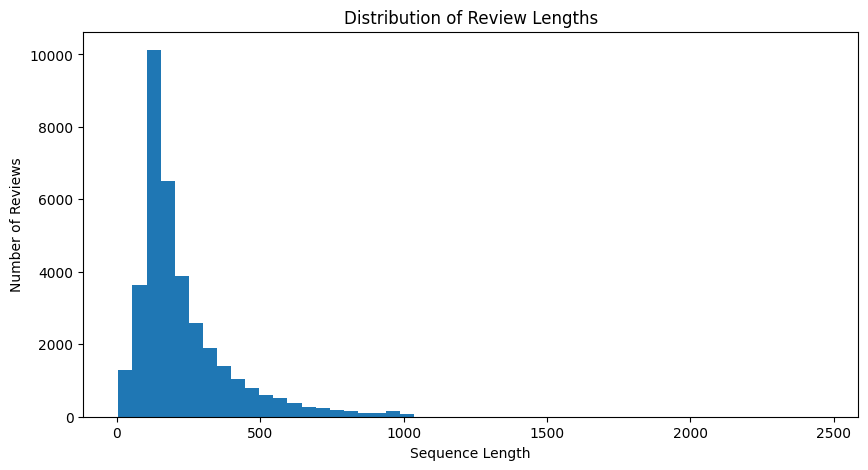

In [75]:
plt.figure(figsize=(10, 5))
plt.hist(sequence_len, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")
plt.show()

In [76]:
print("90th Percentile:", np.percentile(sequence_len, 90))
print("95th Percentile:", np.percentile(sequence_len, 95))
print("99th Percentile:", np.percentile(sequence_len, 99))

90th Percentile: 450.0
95th Percentile: 588.0
99th Percentile: 897.010000000002


In [77]:
max_len=200

x_train_pad=pad_sequences(x_train_seq,maxlen=max_len,padding='post',truncating='post')

x_val_pad=pad_sequences(x_val_seq,maxlen=max_len,padding="post",truncating='post')

x_test_pad=pad_sequences(x_test_seq,maxlen=max_len,padding='post',truncating='post')

print('train: ',x_train_pad.shape)
print('validation: ',x_val_pad.shape)
print('test: ',x_test_pad.shape)

train:  (36000, 200)
validation:  (4000, 200)
test:  (10000, 200)


#----------------Sentiment Classification-------------

#Baseline Model

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

In [79]:
early_stop=EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

In [80]:
# Simple RNN
simple_rnn_model=Sequential([Embedding(vocab,128,input_length=max_len),
                             SimpleRNN(64,return_sequences=False),
                             Dropout(0.5),Dense(1,activation='sigmoid')])

simple_rnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
#training time
start_time=time.time()
history_rnn=simple_rnn_model.fit(x_train_pad,y_train,validation_data=(x_val_pad,y_val),
                                 epochs=10,batch_size=64,
                                 verbose=1)
rnn_training_time=time.time()-start_time

#Evaluation
rnn_loss,rnn_accuracy=simple_rnn_model.evaluate(x_test_pad,y_test,verbose=0)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 59s 101ms/step - accuracy: 0.5042 - loss: 0.6975 - val_accuracy: 0.5148 - val_loss: 0.6921
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.5917 - loss: 0.6541 - val_accuracy: 0.5038 - val_loss: 0.7137
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 55s 98ms/step - accuracy: 0.6680 - loss: 0.5447 - val_accuracy: 0.5060 - val_loss: 0.7968
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 55s 98ms/step - accuracy: 0.7178 - loss: 0.4431 - val_accuracy: 0.5165 - val_loss: 0.9140
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.7400 - loss: 0.4019 - val_accuracy: 0.5213 - val_loss: 0.9618
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 55s 98ms/step - accuracy: 0.7471 - loss: 0.3885 - val_accuracy: 0.5182 - val_loss: 1.0430
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 55s 98ms/step - accuracy: 0.7570 - loss: 0.3750 - val_accuracy: 0.5173 - val_loss: 1.1271
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.7638 - loss: 0.3616 

In [83]:
print("Simple RNN Accuracy: ",rnn_accuracy)
print("Simple RNN Loss: ",rnn_loss)
print("Training Time: ",rnn_training_time,"seconds")

Simple RNN Accuracy:  0.5146999955177307
Simple RNN Loss:  1.2825071811676025
Training Time:  663.2226269245148 seconds


#LSTM Model

In [84]:
lstm_model=Sequential([Embedding(vocab,128),
                       LSTM(128,return_sequences=True),
                       Dropout(0.5),LSTM(64),
                       Dropout(0.5),
                       Dense(1,activation='sigmoid')])

lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
lstm_model.summary()

start_time=time.time()

history_lstm = lstm_model.fit(
    x_train_pad,y_train,
    validation_data=(x_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

lstm_training_time = time.time() - start_time

# Evaluation
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    x_test_pad,
    y_test,
    verbose=0
)

print("\nLSTM Accuracy: ", lstm_accuracy)
print("LSTM Loss: ", lstm_loss)
print("Training Time: ", lstm_training_time, "seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 443s 777ms/step - accuracy: 0.5309 - loss: 0.6887 - val_accuracy: 0.7078 - val_loss: 0.5978
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 436s 774ms/step - accuracy: 0.6542 - loss: 0.6295 - val_accuracy: 0.5000 - val_loss: 0.7154
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 443s 786ms/step - accuracy: 0.7467 - loss: 0.5163 - val_accuracy: 0.8382 - val_loss: 0.3898
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 435s 773ms/step - accuracy: 0.8603 - loss: 0.3474 - val_accuracy: 0.8520 - val_loss: 0.3421
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 436s 775ms/step - accuracy: 0.8916 - loss: 0.2793 - val_accuracy: 0.8683 - val_loss: 0.3143
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 450s 789ms/step - accuracy: 0.9122 - loss: 0.2384 - val_accuracy: 0.8740 - val_loss: 0.3060
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 437s 776ms/step - accuracy: 0.9300 - loss: 0.2014 - val_accuracy: 0.8775 - val_loss: 0.3319
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 440s 782ms/step - accuracy: 0.9447 -

In [86]:
model_1_layer=Sequential([Embedding(vocab,128),
                          LSTM(64),Dropout(0.5),
                          Dense(1,activation='sigmoid')])

model_2_layer=Sequential([Embedding(vocab,128),
                          LSTM(128,return_sequences=True),
                          Dropout(0.5),LSTM(64),
                          Dropout(0.5),Dense(1,activation='sigmoid')])

model_3_layer=Sequential([Embedding(vocab,128),
                          LSTM(256,return_sequences=True),
                          Dropout(0.3),
                          LSTM(128,return_sequences=True),
                          Dropout(0.5),
                          LSTM(64),Dropout(0.7),
                          Dense(1,activation='sigmoid')])

#Bidirectional LSTM

In [88]:
from tensorflow.keras.layers import Bidirectional
bilstm_model=Sequential([Embedding(vocab,128),
                         Bidirectional(LSTM(64,return_sequences=True)),
                         Dropout(0.5),
                         Bidirectional(LSTM(32)),
                         Dense(1,activation='sigmoid')])

bilstm_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
bilstm_model.summary()

#Training Time
start_time=time.time()
history_bilstm=bilstm_model.fit(x_train_pad,y_train,
                                validation_data=(x_val_pad,y_val),
                                epochs=10,batch_size=64,
                                callbacks=[early_stop],
                                verbose=1)

bilstm_training_time=time.time()-start_time

#Evaluation
bilstm_loss,bilstm_accuracy=bilstm_model.evaluate(x_test_pad,y_test,verbose=0)

print("Accuracy: ",bilstm_accuracy)
print("Loss: ",bilstm_loss)
print("Time: ",bilstm_training_time/60,"minutes")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 431s 746ms/step - accuracy: 0.7790 - loss: 0.4667 - val_accuracy: 0.8335 - val_loss: 0.4026
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 449s 758ms/step - accuracy: 0.8772 - loss: 0.3067 - val_accuracy: 0.8675 - val_loss: 0.3195
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 418s 743ms/step - accuracy: 0.9059 - loss: 0.2402 - val_accuracy: 0.8658 - val_loss: 0.3204
Accuracy:  0.84170001745224
Loss:  0.3963378667831421
Time:  22.032537285486857 minutes


#GRU Model

In [89]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(vocab, 128),
    GRU(128, return_sequences=True),
    Dropout(0.5),GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

# Training Time
start_time = time.time()

history_gru = gru_model.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

gru_training_time = time.time() - start_time

# Evaluation
gru_loss, gru_accuracy = gru_model.evaluate(
    x_test_pad,
    y_test,
    verbose=0
)

print("\nGRU Accuracy: ",gru_accuracy)
print("GRU Loss: ",gru_loss)
print("Training Time: ",gru_training_time/60,"minutes")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 455s 797ms/step - accuracy: 0.5382 - loss: 0.6878 - val_accuracy: 0.7122 - val_loss: 0.6389
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 443s 786ms/step - accuracy: 0.8174 - loss: 0.3955 - val_accuracy: 0.8835 - val_loss: 0.2835
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 501s 783ms/step - accuracy: 0.9124 - loss: 0.2236 - val_accuracy: 0.8875 - val_loss: 0.2766
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 444s 789ms/step - accuracy: 0.9436 - loss: 0.1593 - val_accuracy: 0.8742 - val_loss: 0.3268
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 503s 791ms/step - accuracy: 0.9615 - loss: 0.1135 - val_accuracy: 0.8763 - val_loss: 0.3615
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 499s 786ms/step - accuracy: 0.9762 - loss: 0.0767 - val_accuracy: 0.8668 - val_loss: 0.4183

GRU Accuracy:  0.8853999972343445
GRU Loss:  0.27884677052497864
Training Time:  47.41230904658635 minutes


In [90]:
def plot_history(history, title):

    # Accuracy Plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss Plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

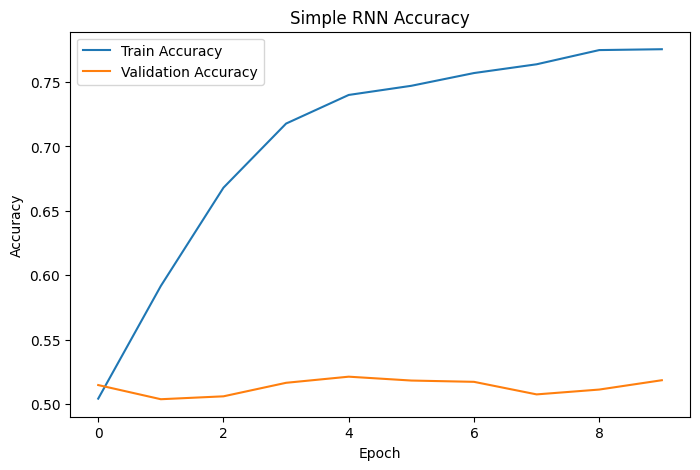

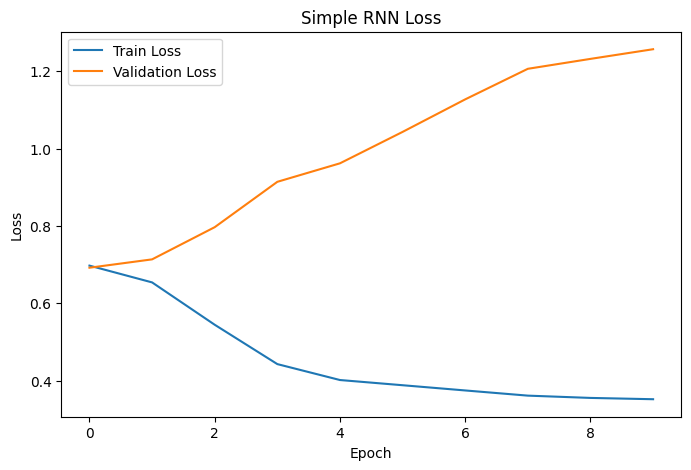

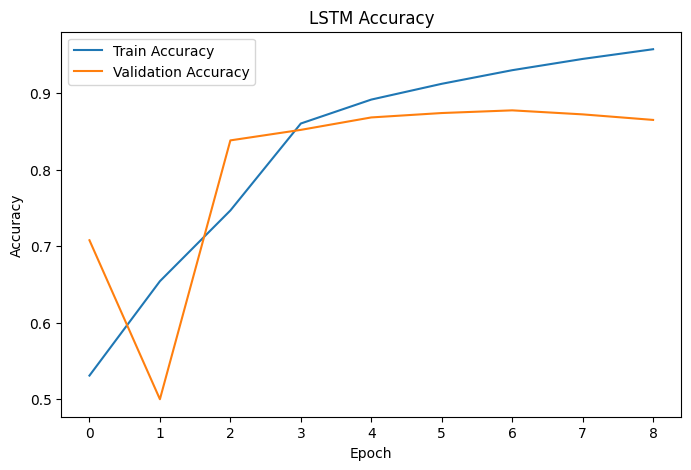

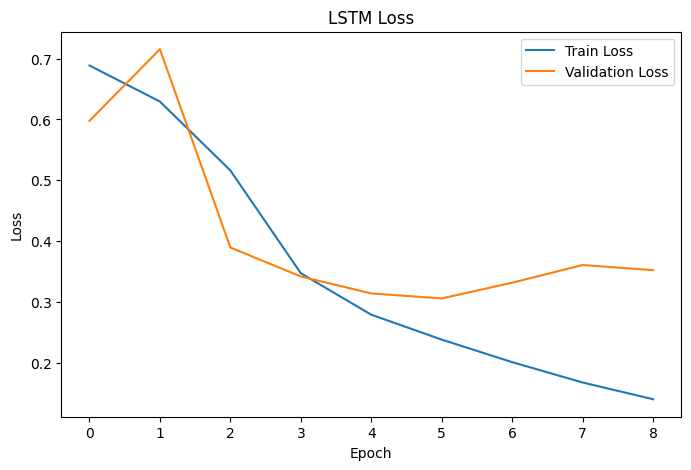

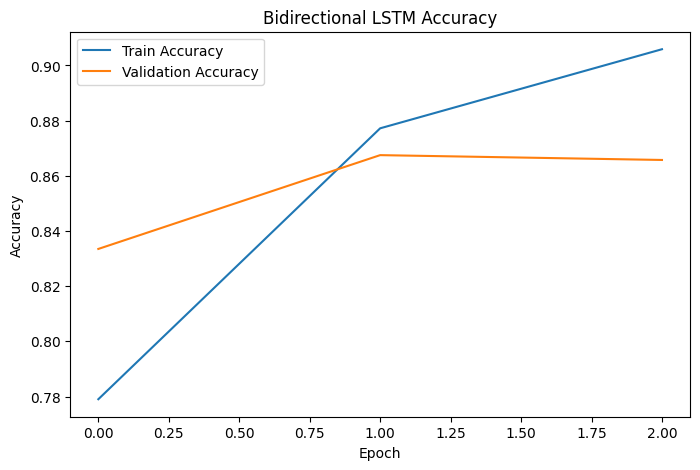

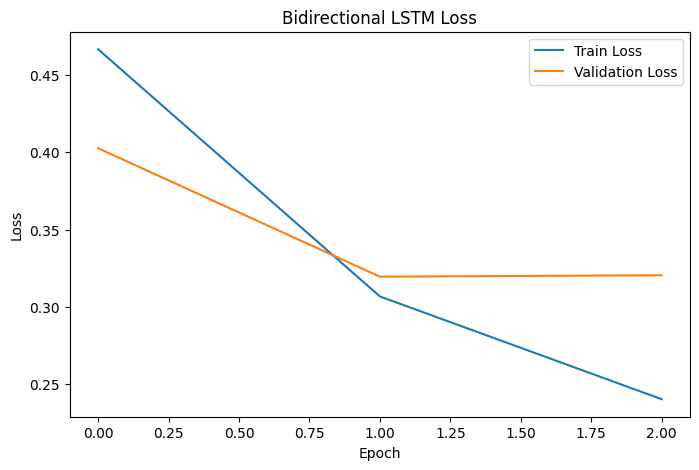

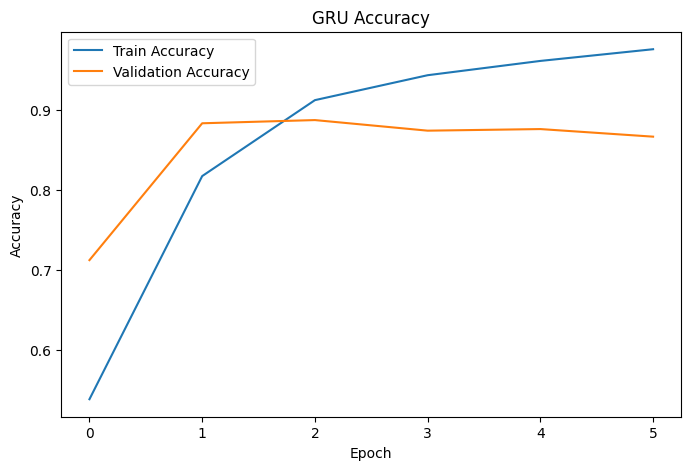

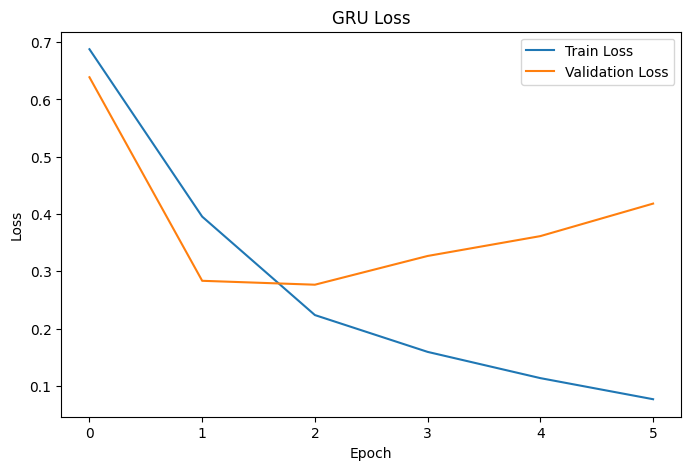

In [91]:
plot_history(history_rnn,"Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_bilstm, "Bidirectional LSTM")
plot_history(history_gru, "GRU")

In [100]:
#Comparison
print(f"Simple RNN Accuracy : {rnn_accuracy:.4f}")
print(f"LSTM Accuracy       : {lstm_accuracy:.4f}")
print(f"BiLSTM Accuracy     : {bilstm_accuracy:.4f}")
print(f"GRU Accuracy        : {gru_accuracy:.4f}")

print("\nTraining Times")
print(f"Simple RNN : {(rnn_training_time/60):.2f} min")
print(f"LSTM       : {(lstm_training_time/60):.2f} min")
print(f"BiLSTM     : {(bilstm_training_time/60):.2f} min")
print(f"GRU        : {(gru_training_time/60):.2f} min")

Simple RNN Accuracy : 0.5147
LSTM Accuracy       : 0.8763
BiLSTM Accuracy     : 0.8417
GRU Accuracy        : 0.8854

Training Times
Simple RNN : 11.05 min
LSTM       : 66.03 min
BiLSTM     : 22.03 min
GRU        : 47.41 min


In [101]:
#No. of Parameters
print("Simple RNN Parameters :", simple_rnn_model.count_params())
print("LSTM Parameters       :", lstm_model.count_params())
print("BiLSTM Parameters     :", bilstm_model.count_params())
print("GRU Parameters        :", gru_model.count_params())

Simple RNN Parameters : 1292417
LSTM Parameters       : 1461057
BiLSTM Parameters     : 1420097
GRU Parameters        : 1416385


In [109]:
models_to_test = {
    "Simple RNN": simple_rnn_model,
    "LSTM": lstm_model,
    "Bi-LSTM": bilstm_model,
    "GRU": gru_model
}

def predict_sentiment(text, model_object, model_name):

    cleaned_text = clean_text(text)
    seq = token.texts_to_sequences([cleaned_text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    prob = model_object.predict(pad, verbose=0)[0][0]

    sentiment = "Positive" if prob >= 0.5 else "Negative"
    print(f"[{model_name}] -> {sentiment} ({prob:.4f})")

# Loop through the dictionary and test your sentences
test_sentences = [
    "This movie was absolutely fantastic!",
    "The film was boring and disappointing"
]

for name, model in models_to_test.items():
    print(f"\n--- Testing {name} ---")
    for sentence in test_sentences:
        predict_sentiment(sentence, model, name)


--- Testing Simple RNN ---
[Simple RNN] -> Positive (0.5703)
[Simple RNN] -> Positive (0.5699)

--- Testing LSTM ---
[LSTM] -> Positive (0.9636)
[LSTM] -> Negative (0.0667)

--- Testing Bi-LSTM ---
[Bi-LSTM] -> Positive (0.6370)
[Bi-LSTM] -> Negative (0.1178)

--- Testing GRU ---
[GRU] -> Positive (0.9647)
[GRU] -> Negative (0.0209)


In [111]:
from tensorflow.keras.models import load_model
Final_sentiment_model= gru_model

Final_sentiment_model.save("Best_gru_sentiment_model.h5")


In [113]:
final_model=load_model("Best_gru_sentiment_model.h5")

In [114]:
import pickle
with open("token.pkl","wb") as f:
  pickle.dump(token,f)